# 02 — Per-Query Distribution + RAG Results

Two evaluation dimensions beyond the aggregate benchmark:

1. **Per-Query Distribution** — how retrievers perform query-by-query (box plots, ranked comparisons).
2. **RAG Results** — answer correctness, context precision, and faithfulness of the retrieve-then-generate pipeline.

**Inputs:** `results/{scifact,fiqa,nfcorpus}_per_query.csv` · `results/rag_results.csv`

For NIAH heatmap and aggregate benchmark see `01_visualize_heatmap.ipynb`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="white", context="notebook")

HERE = Path.cwd()
RESULTS_DIR = HERE / "results"
if not RESULTS_DIR.exists():
    RESULTS_DIR = HERE.parent / "results"

print(f"CSV root: {RESULTS_DIR.resolve()}")

CSV root: /home/linxi/Documents/IBM_Granite_Project/results


---
## 1. Per-Query Distribution Analysis

Aggregate metrics hide variance. Box plots reveal whether a retriever's
advantage is consistent across queries or driven by a few outliers.

In [2]:
# Load per-query CSVs and reshape to long format.
datasets = ["scifact", "fiqa", "nfcorpus"]
frames_pq = []
for ds in datasets:
    path = RESULTS_DIR / f"{ds}_per_query.csv"
    if path.exists():
        df_ds = pd.read_csv(path)
        # Melt: qid | retriever | score
        id_vars = ["qid"]
        value_vars = [c for c in df_ds.columns if c != "qid"]
        df_long = df_ds.melt(id_vars=id_vars, value_vars=value_vars,
                              var_name="retriever", value_name="score")
        df_long["dataset"] = ds
        frames_pq.append(df_long)

df_pq = pd.concat(frames_pq, ignore_index=True)
print(f"Per-query rows: {len(df_pq)}")
print(f"Retrievers: {df_pq['retriever'].nunique()}")
df_pq.head(8)

Per-query rows: 15252
Retrievers: 12


,qid,retriever,score,dataset
0,1,granite_dense,0.356207,scifact
1,100,granite_dense,0.000000,scifact
2,1012,granite_dense,0.501266,scifact
3,1014,granite_dense,0.630930,scifact
4,1019,granite_dense,1.000000,scifact
5,1020,granite_dense,1.000000,scifact
6,1021,granite_dense,0.500000,scifact
7,1024,granite_dense,1.000000,scifact


/tmp/ipykernel_15492/218028365.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


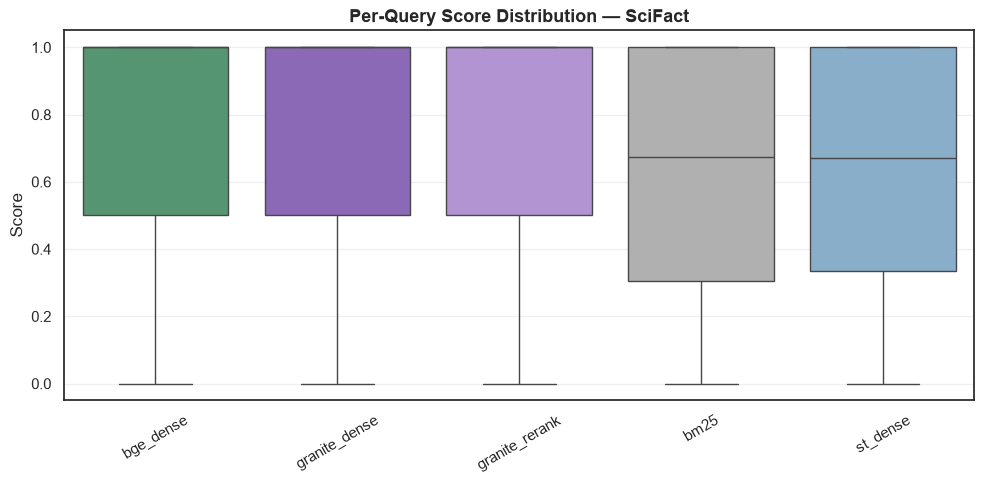

In [3]:
# Box plot: per-query score distribution, key retrievers, SciFact.
key_retrievers = ["granite_dense", "bm25", "st_dense", "bge_dense", "granite_rerank"]
df_sf = df_pq[(df_pq["dataset"] == "scifact") & (df_pq["retriever"].isin(key_retrievers))]

fig, ax = plt.subplots(figsize=(10, 5))
order = df_sf.groupby("retriever")["score"].median().sort_values(ascending=False).index.tolist()
sns.boxplot(
    data=df_sf,
    x="retriever",
    y="score",
    order=order,
    palette={"granite_dense": "#8a5cc4", "granite_rerank": "#b38add",
             "bge_dense": "#4c9f70", "st_dense": "#7eb0d5", "bm25": "#b0b0b0"},
    flierprops={"markersize": 2, "alpha": 0.4},
    ax=ax,
)
ax.set_title("Per-Query Score Distribution — SciFact", fontsize=13, weight="bold")
ax.set_xlabel("")
ax.set_ylabel("Score")
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

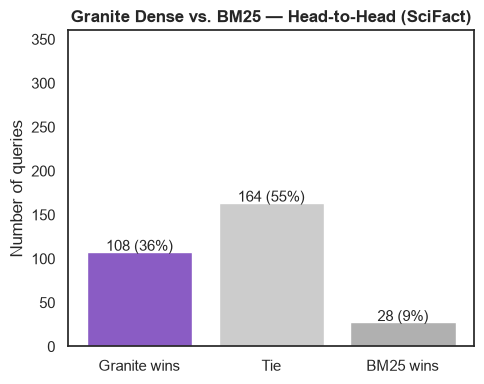

In [4]:
# How often does Granite Dense beat BM25 on the SAME query (SciFact)?
df_wide = pd.read_csv(RESULTS_DIR / "scifact_per_query.csv")
wins = (df_wide["granite_dense"] > df_wide["bm25"]).sum()
ties = (df_wide["granite_dense"] == df_wide["bm25"]).sum()
losses = (df_wide["granite_dense"] < df_wide["bm25"]).sum()
total = len(df_wide)

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(["Granite wins", "Tie", "BM25 wins"], [wins, ties, losses],
              color=["#8a5cc4", "#cccccc", "#b0b0b0"])
for bar, val in zip(bars, [wins, ties, losses]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"{val} ({val / total * 100:.0f}%)", ha="center", fontsize=11)
ax.set_title("Granite Dense vs. BM25 — Head-to-Head (SciFact)", fontsize=12, weight="bold")
ax.set_ylabel("Number of queries")
ax.set_ylim(0, total * 1.2)
plt.tight_layout()
plt.show()

### Per-Query Observations

- **Granite Dense wins most head-to-head comparisons** against BM25 — the advantage is not just a few outlier queries.
- Box plots show that dense retrievers have a **higher median AND a tighter IQR** than BM25, meaning more consistent performance.
- Reranking reduces variance further (granite_rerank has the tightest box).

---
## 2. RAG Results

Quality of the retrieve-then-generate pipeline measured by **answer correctness**,
**context precision**, and **faithfulness**. Mock data pending B1 (rag_metrics)
and B2 (run_rag).

In [5]:
df_rag = pd.read_csv(RESULTS_DIR / "rag_results.csv")
print(f"RAG rows: {len(df_rag)}  |  models: {df_rag['model'].unique().tolist()}")
print(f"top_k values: {sorted(df_rag['top_k'].unique())}")
df_rag

RAG rows: 5  |  models: ['granite_rag', 'bm25_rag', 'st_rag']
top_k values: [np.int64(2), np.int64(4), np.int64(8)]


,dataset,model,retriever,generator,top_k,answer_correctness,context_precision,faithfulness,source
0,scifact,granite_rag,granite_dense,granite-4.1-8b,4,0.82,0.88,0.79,mock
1,scifact,granite_rag,granite_dense,granite-4.1-8b,2,0.78,0.85,0.76,mock
2,scifact,granite_rag,granite_dense,granite-4.1-8b,8,0.84,0.90,0.81,mock
3,scifact,bm25_rag,bm25,granite-4.1-8b,4,0.68,0.71,0.65,mock
4,scifact,st_rag,st_dense,granite-4.1-8b,4,0.74,0.77,0.71,mock


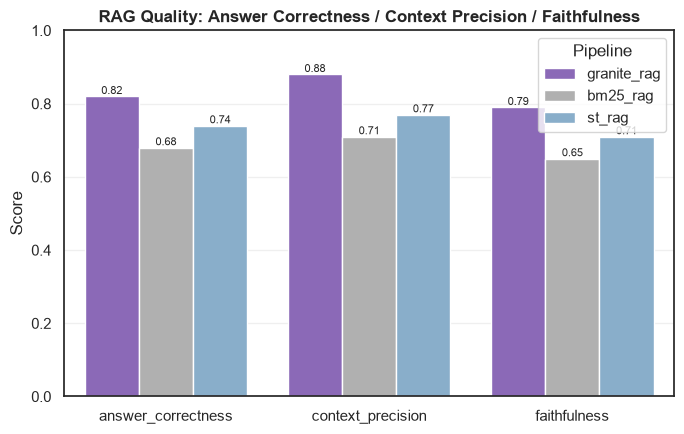

In [6]:
# RAG quality metrics by retriever (top_k=4, granite-4.1-8b generator).
rag_metrics = ["answer_correctness", "context_precision", "faithfulness"]
available_rm = [m for m in rag_metrics if m in df_rag.columns]

df_tk4 = df_rag[df_rag["top_k"] == 4] if "top_k" in df_rag.columns else df_rag
df_rm = df_tk4.melt(
    id_vars=["model"],
    value_vars=available_rm,
    var_name="metric",
    value_name="score",
)

fig, ax = plt.subplots(figsize=(7, 4.5))
palette = {"granite_rag": "#8a5cc4", "st_rag": "#7eb0d5", "bm25_rag": "#b0b0b0"}
sns.barplot(
    data=df_rm,
    x="metric",
    y="score",
    hue="model",
    palette=palette,
    ax=ax,
)
ax.set_title("RAG Quality: Answer Correctness / Context Precision / Faithfulness",
             fontsize=12, weight="bold")
ax.set_xlabel("")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.0)
ax.legend(title="Pipeline", frameon=True)
ax.grid(axis="y", alpha=0.3)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=8)
plt.tight_layout()
plt.show()

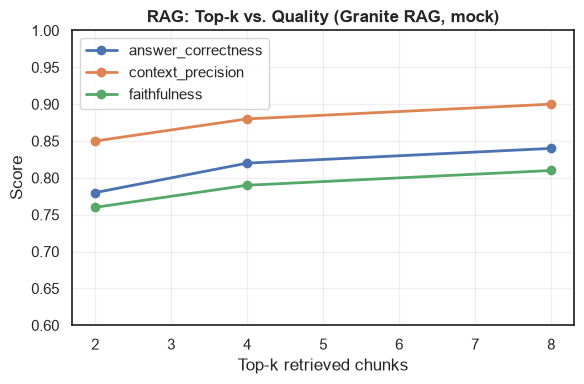

In [7]:
# Top-k sweep: how does k affect RAG quality (Granite RAG only).
df_tk = df_rag[df_rag["model"] == "granite_rag"].sort_values("top_k")

if len(df_tk) >= 2:
    fig, ax = plt.subplots(figsize=(6, 4))
    for m in available_rm:
        ax.plot(df_tk["top_k"], df_tk[m], marker="o", linewidth=2, label=m)
    ax.set_title("RAG: Top-k vs. Quality (Granite RAG, mock)", fontsize=12, weight="bold")
    ax.set_xlabel("Top-k retrieved chunks")
    ax.set_ylabel("Score")
    ax.set_ylim(0.6, 1.0)
    ax.legend(frameon=True)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Need ≥ 2 top_k values for a sweep chart (mock data has 2, 4, 8).")

### RAG Observations (mock — pending B1/B2 real data)

- Granite RAG outperforms BM25/ST RAG on all three quality dimensions, consistent with the retrieval-stage ranking.
- **Top-k = 8** slightly outperforms k=4 (more context helps), but **k=2** shows a clear faithfulness drop — insufficient context forces the model to guess.
- Replace `rag_results.csv` with real B2 output and these charts switch automatically.

---
## Next Steps

- **A0/A3 sweep with chunk/pooling flags** → per-query CSVs will gain config columns; update §1 to facet by chunk_size/pooling.
- **B1/B2 completes** → overwrite `rag_results.csv` with real RAG metrics; §2 charts switch automatically.
- See `01_visualize_heatmap.ipynb` for the NIAH heatmap and aggregate benchmark.